## Problem Statement and Objective

The goal is to predict whether a bank customer will subscribe to a term deposit after a marketing campaign. This helps the bank target potential clients more effectively and improve marketing ROI.

Objective:
Build a classification model to predict subscription (yes/no)

Evaluate model performance using metrics and visualizations

Explain model predictions using Explainable AI (XAI) tools (SHAP)

In [10]:
# ==============================
# STEP 0: Import Libraries
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

# Explainable AI
import shap

In [11]:
# ==============================
# STEP 1: Load Dataset
# ==============================

# Load dataset (replace with local path if needed)
url = "bank-full.csv"
df = pd.read_csv(url, sep=';')

# Preview dataset
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


Shape: (45211, 17)

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None

Missing Values:
age          0
job          0
marital      0


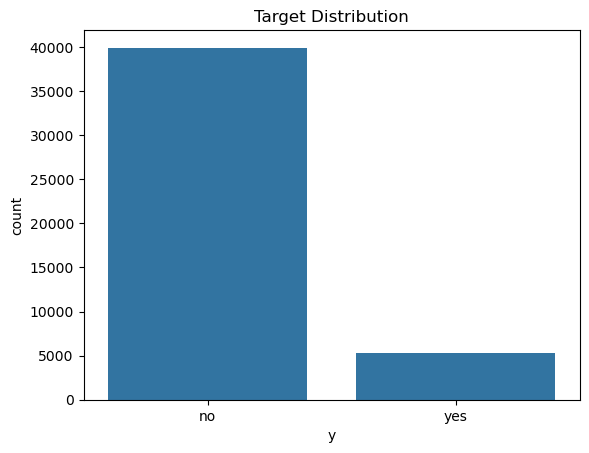


Target Percentage:
y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64


In [12]:
# ==============================
# STEP 2: Explore Dataset
# ==============================

print("Shape:", df.shape)
print("\nData Types:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# Target distribution
sns.countplot(x='y', data=df)
plt.title("Target Distribution")
plt.show()

print("\nTarget Percentage:")
print(df['y'].value_counts(normalize=True))

In [13]:
# ==============================
# STEP 3: Encoding
# ==============================

# Encode y → 0/1
# One-hot encode other categorical features

# Encode target variable
le = LabelEncoder()
df['y'] = le.fit_transform(df['y'])   # no=0, yes=1

# Categorical columns
categorical_cols = [
    'job','marital','education','default',
    'housing','loan','contact','month','poutcome'
]

# One-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df_encoded.head()

,age,balance,day,duration,campaign,pdays,previous,y,job_blue-collar,job_entrepreneur,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,58,2143,5,261,1,-1,0,0,False,False,...,False,False,False,True,False,False,False,False,False,True
1,44,29,5,151,1,-1,0,0,False,False,...,False,False,False,True,False,False,False,False,False,True
2,33,2,5,76,1,-1,0,0,False,True,...,False,False,False,True,False,False,False,False,False,True
3,47,1506,5,92,1,-1,0,0,True,False,...,False,False,False,True,False,False,False,False,False,True
4,33,1,5,198,1,-1,0,0,False,False,...,False,False,False,True,False,False,False,False,False,True


In [14]:
# ==============================
# STEP 4: Train Test Split
# ==============================

X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (36168, 42)
Testing shape: (9043, 42)


Logistic Regression F1 Score: 0.45161290322580644
Logistic Regression ROC-AUC: 0.9006632236956581


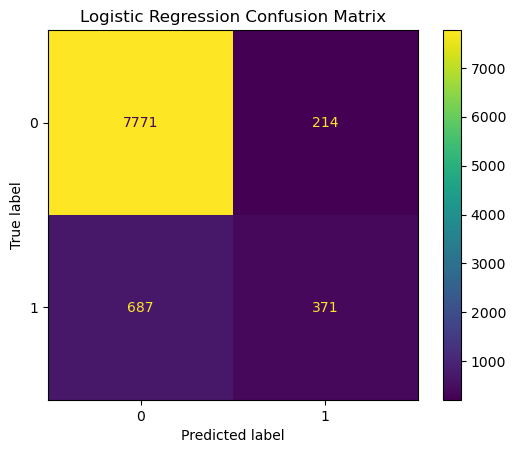

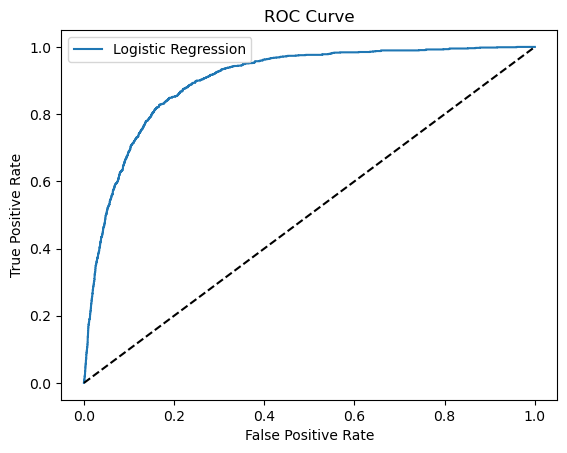

In [15]:
# ==============================
# STEP 5: Logistic Regression
# ==============================

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

print("Logistic Regression F1 Score:",
      f1_score(y_test, y_pred_lr))

print("Logistic Regression ROC-AUC:",
      roc_auc_score(y_test, y_prob_lr))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Random Forest F1 Score: 0.4931506849315068
Random Forest ROC-AUC: 0.9291924958541121


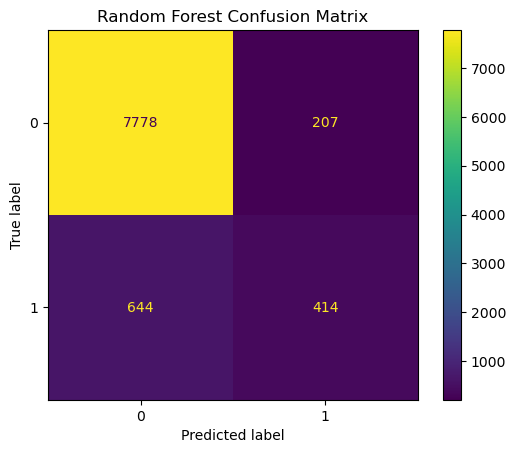

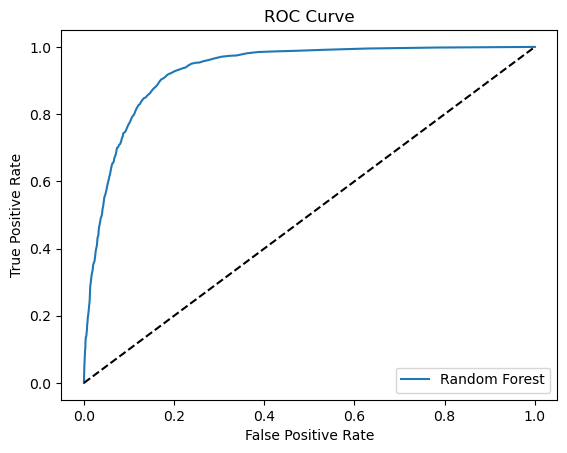

In [16]:
# ==============================
# STEP 6: Random Forest
# ==============================

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1   # Uses all CPU cores
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("Random Forest F1 Score:",
      f1_score(y_test, y_pred_rf))

print("Random Forest ROC-AUC:",
      roc_auc_score(y_test, y_prob_rf))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title("Random Forest Confusion Matrix")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

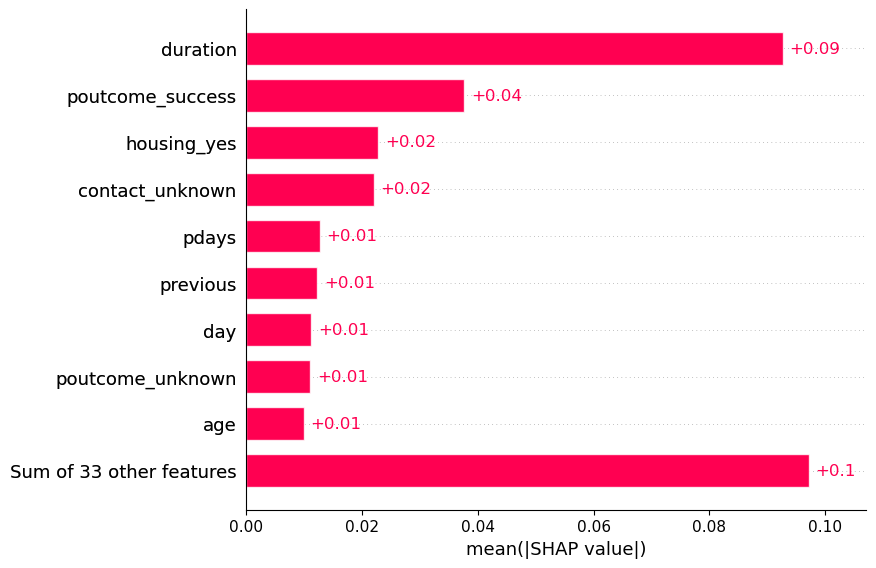

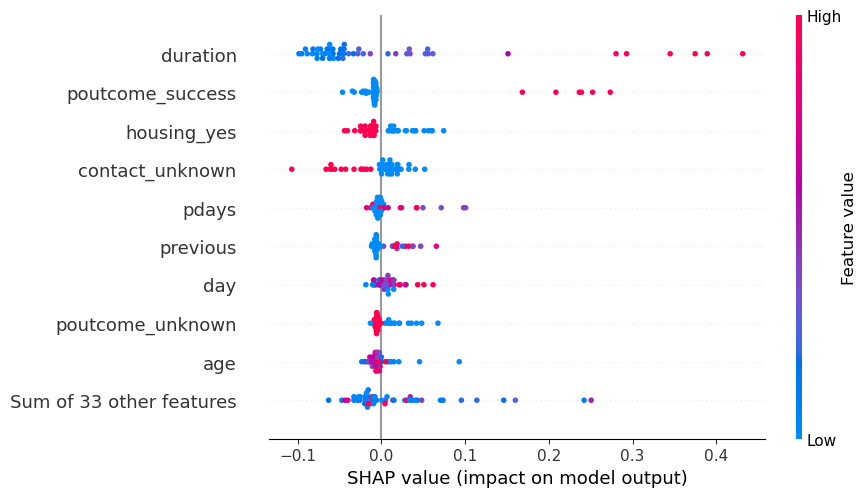

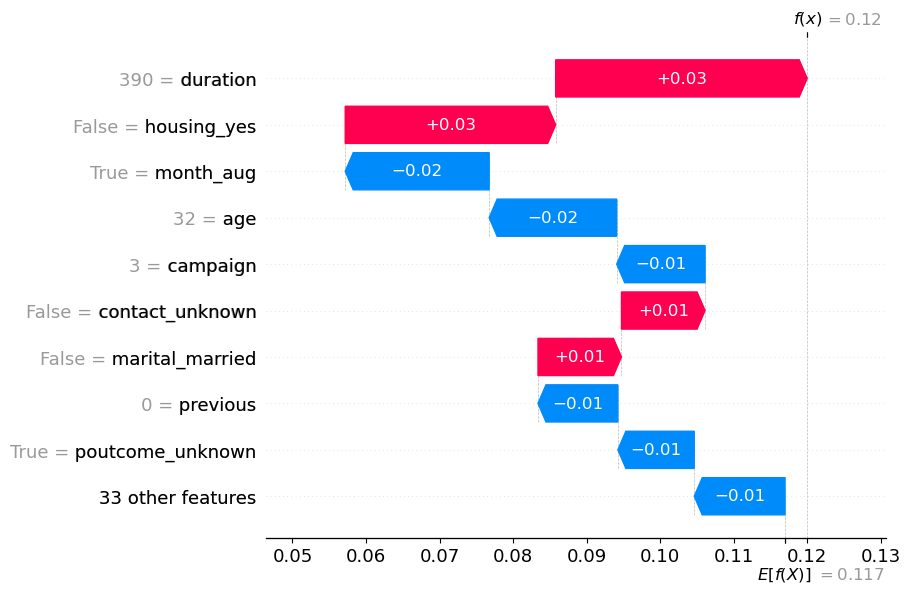

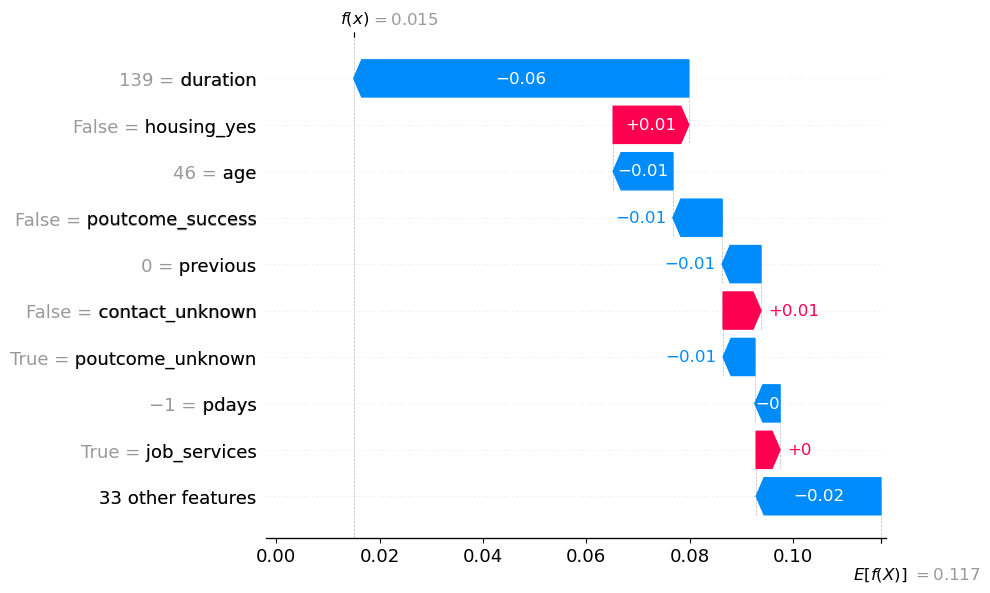

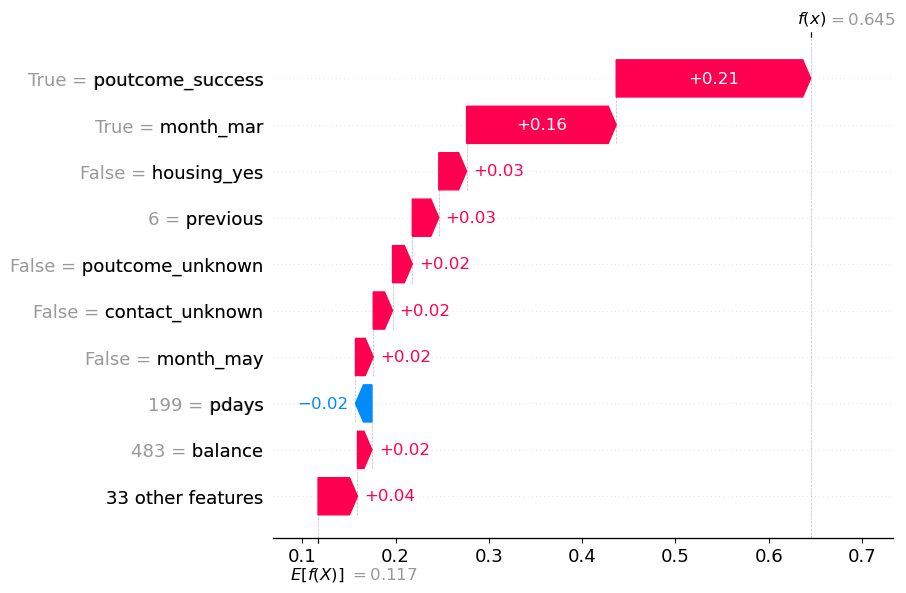

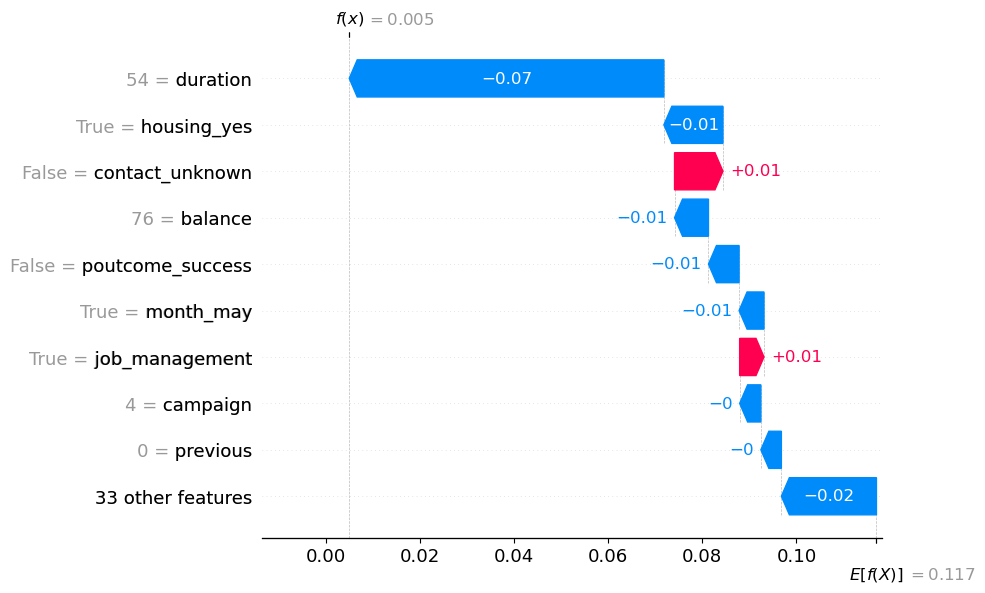

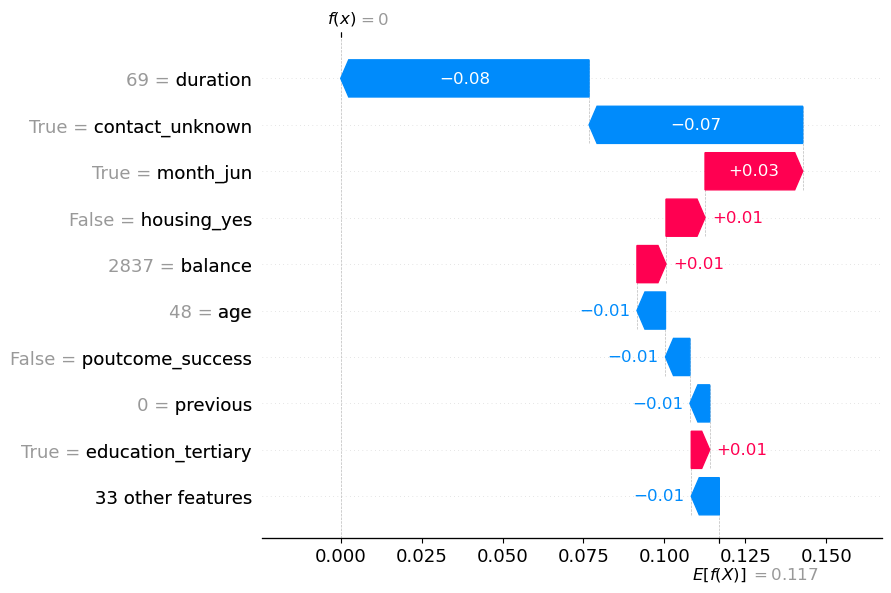

In [19]:
# ==============================
# STEP 7: SHAP (FINAL WORKING VERSION)
# ==============================

import shap

# Take small sample (for speed)
X_test_sample = X_test.sample(n=50, random_state=42)

# Create explainer
explainer = shap.TreeExplainer(rf)

# Compute SHAP values
shap_values = explainer(X_test_sample)

# ------------------------------
# GLOBAL EXPLANATION
# ------------------------------

# For binary classification → class index 1 = "Yes"
shap.plots.bar(shap_values[:, :, 1])
shap.plots.beeswarm(shap_values[:, :, 1])

# ------------------------------
# INDIVIDUAL EXPLANATIONS
# ------------------------------

# Explain 5 individual predictions
for i in range(5):
    shap.plots.waterfall(shap_values[i, :, 1])